In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 匯入必要的套件
import matplotlib.pyplot as plt

# 使用 fivethirtyeight 風格，讓圖表更美觀
# plt.style.use('fivethirtyeight')

# 設定字型，確保中文能正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 設定數學字型，確保負號能正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

# Module 2：線性迴歸

## 資料集說明

| 欄位 | 說明 |
|---|---|
| `CRIM` | 城鎮的人均犯罪率 |
| `ZN` | 大面積住宅用地比例 |
| `INDUS` | 非零售商業用地比例 |
| `CHAS` | 是否鄰近 Charles River，1 代表是，0 代表否 |
| `NOX` | 一氧化氮濃度 |
| `RM` | 平均房間數 |
| `AGE` | 1940 年以前建造的自住房屋比例 |
| `DIS` | 到就業中心的加權距離 |
| `RAD` | 到放射狀公路的便利程度 |
| `TAX` | 房屋稅率 |
| `PTRATIO` | 師生比例 |
| `B` | 與地區人口結構有關的轉換欄位 |
| `LSTAT` | 低收入人口比例 |
| `MEDV` | 房價中位數，本章要預測的目標欄位 |


## 1. 簡單線性迴歸

簡單線性迴歸只使用一個特徵預測一個連續型目標。

本範例使用 `RM`（平均房間數）預測 `MEDV`（房價中位數）。

模型可以想成：

$$
\hat{y} = b + w \times x
$$

其中：

- $x$ 是 `RM`
- $\hat{y}$ 是模型預測的 `MEDV`
- $b$ 是截距
- $w$ 是係數，也可以理解成斜率


In [2]:
# ============================================================
# 1. 讀取資料與初步檢視
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 只在這裡讀取一次資料。
data = pd.read_csv("ex2.csv")

print("資料形狀：", data.shape)
display(data.head())

# info() 可以快速檢查每個欄位的資料型態、非空值數量，以及記憶體使用情況。
display(data.info())

# describe() 可以快速檢查每個數值欄位的平均數、標準差、最小值與最大值。
display(data.describe().round(2))

資料形狀： (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


None

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


In [3]:
# ============================================================
# 1. 簡單線性迴歸：使用 RM 預測 MEDV
# ============================================================

work = data.copy()

# 只使用 RM 這個特徵來預測 MEDV。
X_simple = work[["RM"]]
y = work["MEDV"]

# 建立並訓練簡單線性迴歸模型。
simple_model = LinearRegression()
simple_model.fit(X_simple, y)

# 使用訓練好的模型對訓練資料進行預測。
simple_pred = simple_model.predict(X_simple)

# 計算評估指標：MSE、RMSE、MAE、R²。
simple_mse = mean_squared_error(y, simple_pred)
simple_rmse = np.sqrt(simple_mse)
simple_mae = mean_absolute_error(y, simple_pred)
simple_r2 = r2_score(y, simple_pred)

print("截距：", round(simple_model.intercept_, 4))
print("RM 係數：", round(simple_model.coef_[0], 4))
print("MSE：", round(simple_mse, 4))
print("RMSE：", round(simple_rmse, 4))
print("MAE：", round(simple_mae, 4))
print("R²：", round(simple_r2, 4))

# 使用新資料進行預測，這裡我們使用兩筆 RM 值分別為 6.5 和 7.0 的資料。
newData = [
    [6.5],
    [7.0]
]

# 使用簡單線性迴歸模型預測新資料的 MEDV。
new_pred = simple_model.predict(newData)
print("新資料預測結果：", new_pred.round(2))

截距： -34.6706
RM 係數： 9.1021
MSE： 43.6006
RMSE： 6.6031
MAE： 4.4478
R²： 0.4835
新資料預測結果： [24.49 29.04]


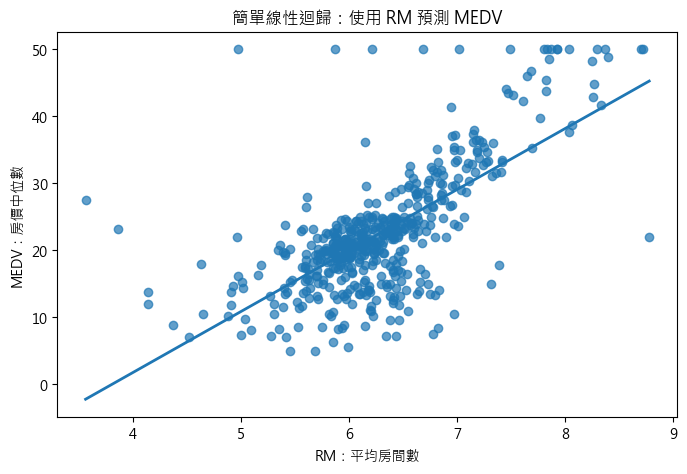

In [4]:
# ============================================================
# 1. 簡單線性迴歸視覺化
# ============================================================
# 使用 matplotlib 畫出散佈圖與迴歸線。

x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_line = simple_model.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y, alpha=0.7)
plt.plot(x_line, y_line, linewidth=2)
plt.xlabel("RM：平均房間數")
plt.ylabel("MEDV：房價中位數")
plt.title("簡單線性迴歸：使用 RM 預測 MEDV")
plt.show()

## 2. 多元線性迴歸與模型評估

多元線性迴歸使用多個特徵一起預測同一個目標。

模型可以寫成：

$$
\hat{y} = b + w_1x_1 + w_2x_2 + \cdots + w_px_p
$$

這裡會使用所有特徵欄位預測 `MEDV`，並示範：

- `train_test_split`
- `StandardScaler` 特徵標準化
- MSE
- RMSE
- MAE
- R²
- 加入新資料進行預測

### 為什麼這裡要加入標準化？

房價資料的特徵尺度差異很大，例如：

- `NOX` 大約是 0.x 的小數
- `RM` 大約是 4 到 9 之間
- `TAX`、`B` 可能是數百

如果直接把不同尺度的特徵放進模型，普通線性迴歸仍然可以訓練，但係數大小會很難直接比較。

因此本範例會先用訓練資料 `X_train` 訓練標準化器，再把訓練資料、測試資料與新資料轉成同一個標準化尺度。

重要觀念：

- `scaler.fit_transform(X_train)`：只能用訓練資料計算平均數與標準差。
- `scaler.transform(X_test)`：測試資料只能使用訓練資料學到的標準化規則。
- `scaler.transform(newData)`：新資料預測前，也必須做相同的標準化。


In [5]:
# ============================================================
# 2. 多元線性迴歸：使用多個特徵預測 MEDV
# ============================================================
# feature_names 決定了後面 X 的欄位順序。
# 因此加入新資料時，newData 也要照這個順序放數值。
#
# 本格加入 StandardScaler：
# 1. 先切分訓練資料與測試資料。
# 2. 只用 X_train 訓練 scaler，避免資料外洩。
# 3. X_train、X_test、newData 都使用同一個 scaler 轉換。

work = data.copy()

feature_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

target_name = "MEDV"

X = work[feature_names]
y = work[target_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# ------------------------------------------------------------
# 標準化：
# fit_transform 只用在訓練資料。
# transform 用在測試資料與未來的新資料。
# ------------------------------------------------------------
multi_scaler = StandardScaler()
X_train_scaled = multi_scaler.fit_transform(X_train)
X_test_scaled = multi_scaler.transform(X_test)

multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train)

y_pred = multi_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("多元線性迴歸測試結果（特徵已標準化）")
print("MSE：", round(mse, 4))
print("RMSE：", round(rmse, 4))
print("MAE：", round(mae, 4))
print("R²：", round(r2, 4))

# 標準化後的係數代表：
# 某個特徵增加 1 個標準差時，MEDV 平均會改變多少。
coef_table = pd.DataFrame({
    "特徵": feature_names,
    "標準化後係數": multi_model.coef_
})
coef_table["係數絕對值"] = coef_table["標準化後係數"].abs()
coef_table = coef_table.sort_values("係數絕對值", ascending=False)
display(coef_table.round(4))

# ------------------------------------------------------------
# 加入新資料預測
# ------------------------------------------------------------
# newData 使用 list 格式。
# 每一個內層 list 是一筆新資料。
#
# 順序必須和 feature_names 完全相同：
# CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT
newData = [
    [0.03, 0.0, 7.00, 0, 0.45, 6.20, 65.0, 4.00, 4, 300, 18.0, 390.0, 10.0],
    [10.0, 0.0, 18.00, 0, 0.70, 4.50, 95.0, 1.50, 24, 666, 20.2, 100.0, 30.0]
]

# 使用同一個 scaler 轉換 newData，確保特徵的尺度與訓練資料一致。
newData_scaled = multi_scaler.transform(newData)
new_pred = multi_model.predict(newData_scaled)

prediction_table = pd.DataFrame({
    "樣本": ["新資料 1", "新資料 2"],
    "預測 MEDV": new_pred
})
display(prediction_table.round(2))

多元線性迴歸測試結果（特徵已標準化）
MSE： 33.449
RMSE： 5.7835
MAE： 3.8429
R²： 0.5892


,特徵,標準化後係數,係數絕對值
12,LSTAT,-3.5925,3.5925
7,DIS,-2.8809,2.8809
5,RM,2.5732,2.5732
10,PTRATIO,-2.2928,2.2928
8,RAD,2.1122,2.1122
9,TAX,-1.8753,1.8753
4,NOX,-1.8551,1.8551
1,ZN,1.0571,1.0571
0,CRIM,-0.9708,0.9708
11,B,0.7182,0.7182


,樣本,預測 MEDV
0,新資料 1,25.20
1,新資料 2,3.46


## 3. K-fold Cross Validation

雖然本章主題是線性迴歸，但為了讓學生看到「不同資料切分下，模型結果可能不同」，這裡用 5-fold cross validation 檢視每一個 fold 的訓練與驗證結果。

本範例使用的模型仍然是簡單的 `LinearRegression`。


In [6]:
# ============================================================
# 3. 5-fold Cross Validation
# ============================================================
# 每一個 fold 都會重新訓練一個 LinearRegression 模型。
# 這樣可以觀察模型在不同訓練/驗證切分下的表現是否穩定。
#
# 注意：
# Cross Validation 裡面也要避免資料外洩。
# 所以每一個 fold 都要各自建立 scaler，
# 並且只能用該 fold 的訓練資料 fit scaler。

kf = KFold(n_splits=5, shuffle=True, random_state=0)

fold_results = []
fold_no = 1

for train_index, valid_index in kf.split(X):
    # X 和 y 都保留 pandas 格式時，使用 iloc 依照「位置」取出 fold。
    X_train_fold = X.iloc[train_index]
    X_valid_fold = X.iloc[valid_index]
    y_train_fold = y.iloc[train_index]
    y_valid_fold = y.iloc[valid_index]

    # 每一個 fold 都要各自建立 scaler，並且只能用該 fold 的訓練資料 fit scaler。
    fold_scaler = StandardScaler()
    X_train_fold_scaled = fold_scaler.fit_transform(X_train_fold)
    X_valid_fold_scaled = fold_scaler.transform(X_valid_fold)

    # 每一個 fold 都會重新訓練一個 LinearRegression 模型。
    fold_model = LinearRegression()
    fold_model.fit(X_train_fold_scaled, y_train_fold)

    # 評估訓練資料與驗證資料的表現。
    train_r2 = fold_model.score(X_train_fold_scaled, y_train_fold)
    valid_pred = fold_model.predict(X_valid_fold_scaled)
    valid_rmse = np.sqrt(mean_squared_error(y_valid_fold, valid_pred))
    valid_r2 = r2_score(y_valid_fold, valid_pred)

    fold_results.append({
        "fold": fold_no,
        "訓練 R²": train_r2,
        "驗證 RMSE": valid_rmse,
        "驗證 R²": valid_r2
    })

    # 每一個 fold 結束後，fold_no 加 1。
    fold_no = fold_no + 1

fold_table = pd.DataFrame(fold_results)
display(fold_table.round(4))

print("平均驗證 RMSE：", round(fold_table["驗證 RMSE"].mean(), 4))
print("平均驗證 R²：", round(fold_table["驗證 R²"].mean(), 4))

,fold,訓練 R²,驗證 RMSE,驗證 R²
0,1,0.7730,5.7835,0.5892
1,2,0.7292,4.3196,0.7780
2,3,0.7490,4.6081,0.6679
3,4,0.7566,5.4058,0.6680
4,5,0.7050,4.0711,0.8395


平均驗證 RMSE： 4.8376
平均驗證 R²： 0.7085


## 4. 共線性 與 變異膨脹因子（Variance Inflation Factor，VIF）

共線性是指特徵之間彼此高度相關。若多個特徵提供高度重複的資訊，線性迴歸的係數可能變得不穩定。

VIF 可以用來檢查某一個特徵是否能被其他特徵高度解釋：

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

常見判讀：

| VIF | 解讀 |
|---|---|
| 1 | 幾乎沒有共線性 |
| 1 到 5 | 通常可接受 |
| 大於等於 5 | 可能需要注意 |
| 大於等於 10 | 常被視為嚴重共線性 |


In [7]:
# ============================================================
# 4. 共線性與 VIF
# ============================================================
# 這裡不用額外套件，直接用 LinearRegression 計算每個特徵的 R²，再換算 VIF。
#
# 補充：
# VIF 檢查的是「某個特徵能不能被其他特徵解釋」。
# 標準化只會改變特徵的尺度，不會改變特徵之間的線性關係。
# 因此 VIF 可以直接使用原始特徵計算。

work = data.copy()

# 計算特徵之間的相關係數矩陣。
corr = work[feature_names].corr()

# 找出相關係數絕對值大於等於 0.7 的特徵組合。
strong_pairs = []

for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        # i 和 j 是特徵的索引，feature_names[i] 和 feature_names[j] 是特徵名稱。
        feature_a = feature_names[i]
        feature_b = feature_names[j]

        # corr_value 是 feature_a 和 feature_b 這對特徵的相關係數。
        # 相關係數愈高，表示這兩個特徵之間的線性關係愈強，可能存在共線性問題。
        corr_value = corr.loc[feature_a, feature_b]

        # 如果相關係數的絕對值大於等於 0.7，就把這對特徵加入 strong_pairs。
        # 共線性看的是「是否有強烈線性關係」，不一定只看正相關。
        if abs(corr_value) >= 0.7:
            strong_pairs.append({
                "特徵 A": feature_a,
                "特徵 B": feature_b,
                "相關係數": corr_value
            })

print("相關係數絕對值大於等於 0.7 的特徵組合：")
display(pd.DataFrame(strong_pairs).round(4))

# 計算 VIF 的結果會放在 vif_results 這個 list 裡面。
vif_results = []

# 建立用於計算 VIF 的特徵矩陣。
X_for_vif = work[feature_names]

for i in range(len(feature_names)):
    # current_feature 是目前正在計算 VIF 的特徵名稱。
    current_feature = feature_names[i]

    # 這個 y_feature 是 current_feature 這個特徵的數值，我們要看看其他特徵能不能解釋它。
    y_feature = X_for_vif[current_feature]

    # 其他特徵作為解釋變數，訓練一個線性迴歸模型來預測 y_feature。
    other_features = feature_names.copy()

    # 移除當前特徵，剩下的特徵作為解釋變數。
    other_features.remove(current_feature)

    # X_other 是用來預測 y_feature 的其他特徵的數值。
    X_other = X_for_vif[other_features]

    # 用其他特徵解釋此特徵，訓練模型，並計算 R²，
    # 如果 R² 非常接近 1，VIF 就會趨近無限大，
    # 這表示 current_feature 幾乎完全被其他特徵解釋了，
    # 存在嚴重的共線性問題。
    vif_model = LinearRegression()
    vif_model.fit(X_other, y_feature)
    r2_for_feature = vif_model.score(X_other, y_feature)

    # 計算 VIF，避免 R² 接近 1 時除以零。
    if r2_for_feature >= 0.999999:
        vif_value = np.inf # np.inf 的意思是無限大，表示共線性非常嚴重。
    else:
        vif_value = 1 / (1 - r2_for_feature)

    vif_results.append({
        "特徵": current_feature,
        "R²：用其他特徵解釋此特徵": r2_for_feature,
        "VIF": vif_value
    })

vif_table = pd.DataFrame(vif_results)
vif_table = vif_table.sort_values("VIF", ascending=False)
display(vif_table.round(4))

相關係數絕對值大於等於 0.7 的特徵組合：


,特徵 A,特徵 B,相關係數
0,INDUS,NOX,0.7637
1,INDUS,DIS,-0.7080
2,INDUS,TAX,0.7208
3,NOX,AGE,0.7315
4,NOX,DIS,-0.7692
5,AGE,DIS,-0.7479
6,RAD,TAX,0.9102


,特徵,R²：用其他特徵解釋此特徵,VIF
9,TAX,0.8890,9.0086
8,RAD,0.8664,7.4845
4,NOX,0.7724,4.3937
2,INDUS,0.7495,3.9916
7,DIS,0.7472,3.9559
6,AGE,0.6775,3.1008
12,LSTAT,0.6600,2.9415
1,ZN,0.5650,2.2988
5,RM,0.4829,1.9337
10,PTRATIO,0.4442,1.7991


## 5. 殘差分析

殘差是：

$$
殘差 = 真實值 - 預測值
$$

殘差分析常檢查三件事：

1. **常態性**：殘差是否大致接近常態分布。
2. **獨立性**：殘差之間是否有明顯自相關。
3. **變異數同質性**：不同預測值附近的殘差散布是否差不多。

,真實值,預測值,殘差
329,22.6,24.8896,-2.2896
371,50.0,23.7214,26.2786
219,23.0,29.3650,-6.3650
403,8.3,12.1224,-3.8224
78,21.2,21.4438,-0.2438


常態性檢查
Shapiro-Wilk p-value： 0.0
拒絕 H0，殘差可能明顯偏離常態分布。
Kolmogorov-Smirnov p-value： 0.006229
拒絕 H0，殘差可能明顯偏離常態分布。
D'Agostino-Pearson p-value： 0.0
拒絕 H0，殘差可能明顯偏離常態分布。
Jarque-Bera p-value： 0.0
拒絕 H0，殘差可能明顯偏離常態分布。
獨立性檢查
Durbin-Watson statistic： 2.044
判斷結果：Durbin-Watson 接近 2，殘差沒有明顯一階自相關。


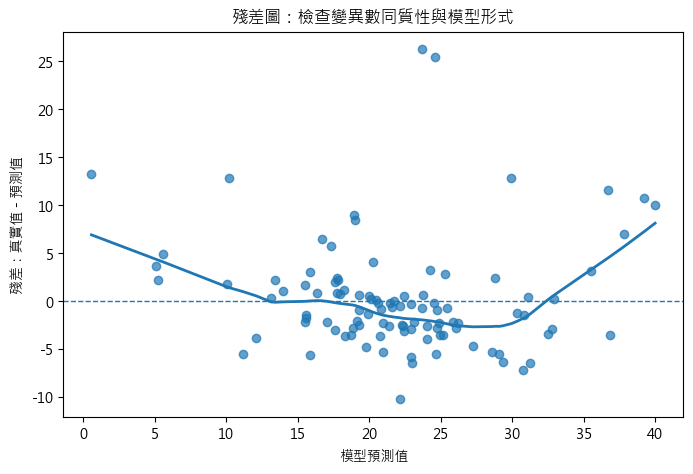

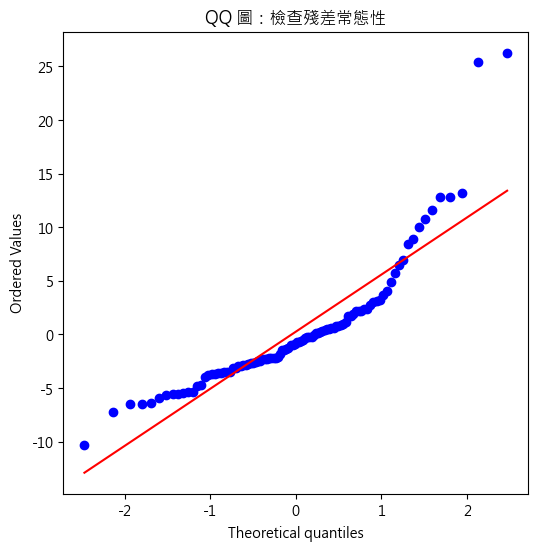

In [8]:
# ============================================================
# 5. 殘差分析：常態性、獨立性、變異數同質性
# ============================================================
# p-value 很小時，通常代表資料明顯不符合該檢定的原假設。

from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess

# 殘差是「真實值 - 預測值」，用來檢查模型的假設是否成立。
residuals = y_test - y_pred

# 建立一個 DataFrame 來顯示真實值、預測值和殘差，方便檢視。
residual_table = pd.DataFrame({
    "真實值": y_test,
    "預測值": y_pred,
    "殘差": residuals
})

display(residual_table.head().round(4))

# alpha 是常態性檢定的顯著水準，通常設定為 0.05。
alpha = 0.05
def normality_result_text(p_value):
    if p_value >= alpha:
        result_text = "未拒絕 H0，殘差沒有明顯偏離常態分布。"
    else:
        result_text = "拒絕 H0，殘差可能明顯偏離常態分布。"
    
    return result_text



print("常態性檢查")

# Shapiro-Wilk 是常態性檢定中最常用的檢定方法之一，適合小樣本。
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value：", round(shapiro_p, 6))
print(normality_result_text(shapiro_p))

# Kolmogorov-Smirnov Test (KS test) 檢定
# 是另一種常態性檢定方法，適合較大樣本，對於小樣本可能不太敏感。
ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
print("Kolmogorov-Smirnov p-value：", round(ks_p, 6))
print(normality_result_text(ks_p))

# D'Agostino-Pearson 檢定，用於同時檢查偏態和峰態。
# 需要至少 8 筆資料才能進行。
if len(residuals) >= 8:
    dagostino_stat, dagostino_p = stats.normaltest(residuals)
    print("D'Agostino-Pearson p-value：", round(dagostino_p, 6))
    print(normality_result_text(dagostino_p))
else:
    print("D'Agostino-Pearson 檢定需要至少 8 筆資料，無法進行檢定。")

# Jarque-Bera 檢定是另一種常態性檢定方法，使用偏態和峰態來檢查常態性。
jarque_stat, jarque_p = stats.jarque_bera(residuals)
print("Jarque-Bera p-value：", round(jarque_p, 6))
print(normality_result_text(jarque_p))


print("獨立性檢查")

# Durbin-Watson 統計量的計算方式是：將相鄰殘差的差值平方後求和，然後除以殘差平方的總和。
residual_diff = np.diff(residuals)
dw_value = np.sum(residual_diff ** 2) / np.sum(residuals ** 2)
print("Durbin-Watson statistic：", round(dw_value, 4))
if dw_value >= 1.5 and dw_value <= 2.5:
    # 一階自相關 代表殘差與其前一個殘差之間存在線性關係，
    # 也就是目前這一期的誤差或殘差，和「前一期」的誤差或殘差有關係。
    print("判斷結果：Durbin-Watson 接近 2，殘差沒有明顯一階自相關。")
elif dw_value < 1.5:
    print("判斷結果：Durbin-Watson 明顯小於 2，殘差可能有正自相關。")
else:
    print("判斷結果：Durbin-Watson 明顯大於 2，殘差可能有負自相關。")



# 局部加權散點平滑法 (Locally Weighted Scatterplot Smoothing, LOWESS)
'''
殘差圖：觀察殘差是否隨預測值呈現系統性模式（系統性偏差）。
系統性模式是指殘差隨預測值呈現某種規律性的變化，
例如呈現 U 型、倒 U 型、或其他非隨機的分布。
代表模型犯錯有規律，模型還有東西沒學到。
正常來說，應該是貼在水平線附近，代表殘差沒有隨預測值呈現系統性模式。

參數說明：
residuals 是「真實值 - 預測值」，用來檢查模型的假設是否成立。
y_pred 是模型對測試資料的預測值。
frac 參數決定了 LOWESS 平滑曲線的靈敏度，值越小，曲線越貼近資料點，值越大，曲線越平滑。
return_sorted=True 代表 LOWESS 的輸出會按照預測值的大小排序，

回傳格式：
[
    [y_pred_小, 平滑後的殘差],
    [y_pred_中, 平滑後的殘差],
    [y_pred_大, 平滑後的殘差]
]
'''
lowess_result = lowess(residuals, y_pred, frac=0.5, return_sorted=True)
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.plot(lowess_result[:, 0], lowess_result[:, 1], linewidth=2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("模型預測值")
plt.ylabel("殘差：真實值 - 預測值")
plt.title("殘差圖：檢查變異數同質性與模型形式")
plt.show()

# QQ 圖：觀察殘差是否大致接近常態分布。
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ 圖：檢查殘差常態性")
plt.show()

## 6. 正規化的線性迴歸

Ridge、Lasso、Elastic Net 都是在普通線性迴歸的基礎上加入正規化，目的是讓模型不要過度依賴某些特徵。

| 模型 | 正規化方式 | 特色 |
|---|---|---|
| Ridge | L2 | 讓係數變小，通常不會變成 0 |
| Lasso | L1 | 可能把部分係數壓成 0，可做特徵選擇 |
| Elastic Net | L1 + L2 | 同時混合 Ridge 與 Lasso 的想法 |

因為正規化會比較不同特徵的係數大小，所以通常要先做標準化。


RidgeCV 最佳 alpha：
6.25055192527397


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

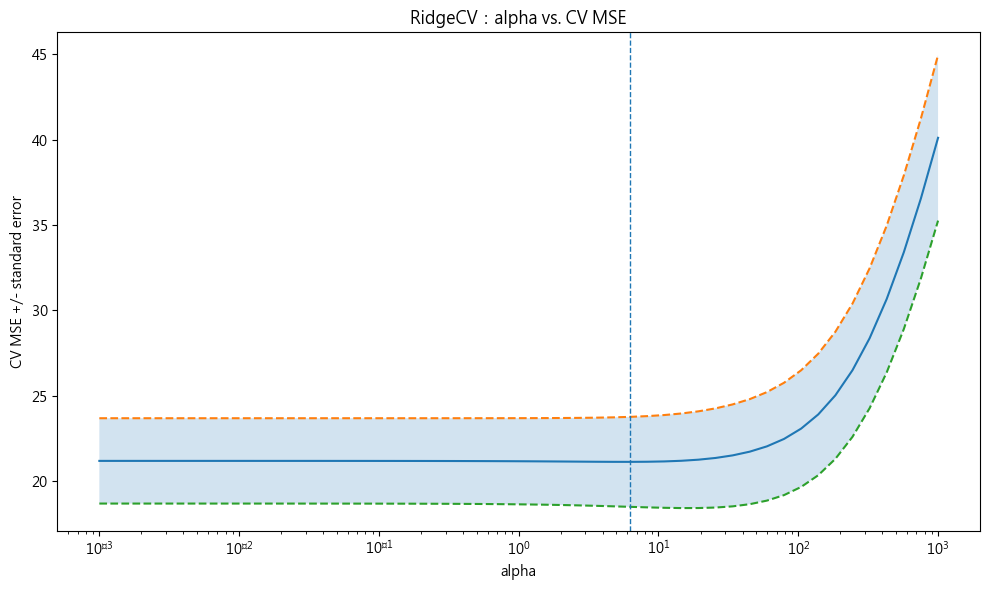

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Ridge 測試資料 MSE：
33.977082638386555
LassoCV 最佳 alpha：
0.018420699693267144


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

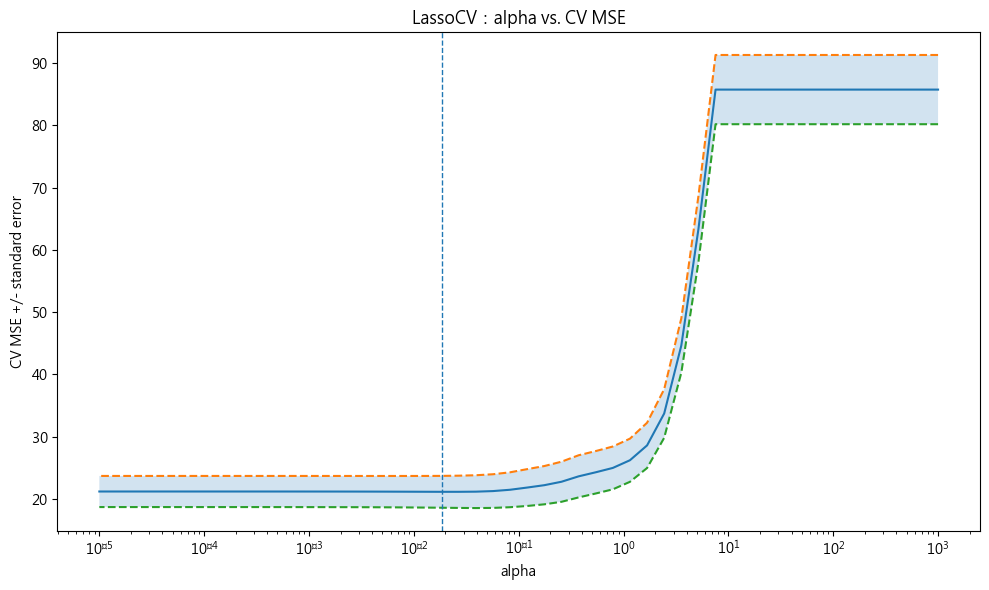

Lasso 測試資料 MSE：
33.70982066095655
Elastic Net 測試資料 MSE：
33.69291906690353


,模型,alpha,l1_ratio,測試資料 MSE
0,RidgeCV,6.2506,不適用,33.9771
1,LassoCV,0.0184,不適用,33.7098
2,Elastic Net,0.0100,0.5,33.6929


,特徵,RidgeCV 係數,LassoCV 係數,Elastic Net 係數
0,CRIM,-0.9240,-0.9135,-0.9390
1,ZN,0.9682,0.9931,1.0089
2,INDUS,-0.0991,-0.0000,-0.0204
3,CHAS,0.6165,0.5936,0.6021
4,NOX,-1.6580,-1.7674,-1.7635
5,RM,2.6294,2.5978,2.6001
6,AGE,-0.1282,-0.0532,-0.0929
7,DIS,-2.6896,-2.7398,-2.7781
8,RAD,1.7110,1.8381,1.8952
9,TAX,-1.5192,-1.6456,-1.6850


In [9]:
# ============================================================
# 6. RidgeCV、LassoCV、Elastic Net
# ============================================================
# Ridge、Lasso、Elastic Net 都是正則化線性迴歸模型。
#
# Ridge：
#   會縮小係數，但通常不會讓係數變成 0。
#
# Lasso：
#   會縮小係數，而且可能把部分係數壓成 0，
#   因此可以做簡單的特徵選擇。
#
# Elastic Net：
#   結合 Ridge 和 Lasso。
#
# 如果 standard error 很大，代表：
# 1. 模型在不同的訓練/驗證切分下表現不穩定。
# 2. 這個 alpha 的表現不太穩定，可能某些 fold 很好，某些 fold 很差。
# 3. 模型可能對資料中的噪音過度敏感。
# 
# 這時候可以考慮：
# 1. 收集更多資料，讓模型有更多樣本可以學習。
# 2. 使用正則化模型（例如 Ridge、Lasso、Elastic Net）來減少模型的複雜度，降低對噪音的敏感度。
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.linear_model import LassoCV, Lasso
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# ============================================================
# 1. 標準化資料
# ============================================================
# Ridge、Lasso、Elastic Net 對特徵尺度敏感，
# 因此要先做標準化。
#
# 注意：
#   scaler 只能用訓練資料 fit。
#   測試資料只能 transform。
# ============================================================

work = data.copy()
X = work[feature_names]
y = work[target_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

regularized_scaler = StandardScaler()
X_train_regularized = regularized_scaler.fit_transform(X_train)
X_test_regularized = regularized_scaler.transform(X_test)


# ============================================================
# 2. RidgeCV：用交叉驗證選擇最佳 alpha
# ============================================================

ridge_alphas = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(
    alphas=ridge_alphas,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_cv.fit(X_train_regularized, y_train)

print("RidgeCV 最佳 alpha：")
print(ridge_cv.alpha_)


# ============================================================
# 3. RidgeCV：畫出 alpha vs. CV MSE +/- standard error
# ============================================================
# 因為新版 RidgeCV 不再使用 store_cv_values，
# 所以這裡用 cross_val_score 逐一計算每個 alpha 的 CV MSE。
# ============================================================

ridge_scores = []
ridge_std_errors = []

for alpha_value in ridge_alphas:
    ridge_temp_model = Ridge(alpha=alpha_value)

    neg_mse_scores = cross_val_score(
        ridge_temp_model,
        X_train_regularized,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )
    mse_scores = -neg_mse_scores
    mse_mean = mse_scores.mean()
    mse_std = mse_scores.std()
    mse_std_error = mse_std / np.sqrt(5)

    ridge_scores.append(mse_mean)
    ridge_std_errors.append(mse_std_error)

ridge_scores = np.array(ridge_scores)
ridge_std_errors = np.array(ridge_std_errors)

plt.figure(figsize=(10, 6))

plt.semilogx(
    ridge_alphas,
    ridge_scores
)

plt.semilogx(
    ridge_alphas,
    ridge_scores + ridge_std_errors,
    linestyle="--"
)

plt.semilogx(
    ridge_alphas,
    ridge_scores - ridge_std_errors,
    linestyle="--"
)

plt.fill_between(
    ridge_alphas,
    ridge_scores + ridge_std_errors,
    ridge_scores - ridge_std_errors,
    alpha=0.2
)

plt.axvline(
    ridge_cv.alpha_,
    linestyle="--",
    linewidth=1
)

plt.xlabel("alpha")
plt.ylabel("CV MSE +/- standard error")
plt.title("RidgeCV：alpha vs. CV MSE")
plt.tight_layout()
plt.show()


# ============================================================
# 4. 使用最佳 alpha 建立 Ridge 模型，並計算測試資料 MSE
# ============================================================

ridge_model = Ridge(alpha=ridge_cv.alpha_)
ridge_model.fit(X_train_regularized, y_train)
ridge_pred = ridge_model.predict(X_test_regularized)
ridge_mse = mean_squared_error(y_test, ridge_pred)
print("Ridge 測試資料 MSE：")
print(ridge_mse)


# ============================================================
# 5. LassoCV：用交叉驗證選擇最佳 alpha
# ============================================================

lasso_alphas = np.logspace(-5, 3, 50)

lasso_cv = LassoCV(
    alphas=lasso_alphas,
    cv=5,
    max_iter=10000,
    random_state=0
)

lasso_cv.fit(X_train_regularized, y_train)

print("LassoCV 最佳 alpha：")
print(lasso_cv.alpha_)


# ============================================================
# 6. LassoCV：畫出 alpha vs. CV MSE +/- standard error
# ============================================================
# lasso_cv.mse_path_：
#   每個 alpha 在每一折交叉驗證中的 MSE。
# ============================================================

lasso_scores = np.mean(lasso_cv.mse_path_, axis=1)
lasso_scores_std = np.std(lasso_cv.mse_path_, axis=1)
lasso_std_errors = lasso_scores_std / np.sqrt(5)

plt.figure(figsize=(10, 6))

plt.semilogx(
    lasso_cv.alphas_,
    lasso_scores
)

plt.semilogx(
    lasso_cv.alphas_,
    lasso_scores + lasso_std_errors,
    linestyle="--"
)

plt.semilogx(
    lasso_cv.alphas_,
    lasso_scores - lasso_std_errors,
    linestyle="--"
)

plt.fill_between(
    lasso_cv.alphas_,
    lasso_scores + lasso_std_errors,
    lasso_scores - lasso_std_errors,
    alpha=0.2
)

plt.axvline(
    lasso_cv.alpha_,
    linestyle="--",
    linewidth=1
)

plt.xlabel("alpha")
plt.ylabel("CV MSE +/- standard error")
plt.title("LassoCV：alpha vs. CV MSE")

plt.tight_layout()
plt.show()


# ============================================================
# 7. 使用最佳 alpha 建立 Lasso 模型，並計算測試資料 MSE
# ============================================================

lasso_model = Lasso(
    alpha=lasso_cv.alpha_,
    max_iter=10000
)

lasso_model.fit(X_train_regularized, y_train)
lasso_pred = lasso_model.predict(X_test_regularized)
lasso_mse = mean_squared_error(y_test, lasso_pred)

print("Lasso 測試資料 MSE：")
print(lasso_mse)


# ============================================================
# 8. Elastic Net
# ============================================================
# Elastic Net 是 Ridge 和 Lasso 的混合。
#
# alpha：
#   控制正則化強度。
#
# l1_ratio：
#   控制 Lasso 和 Ridge 的比例。
#
#   l1_ratio = 1.0 代表接近 Lasso
#   l1_ratio = 0.0 代表接近 Ridge
#   l1_ratio = 0.5 代表兩者各佔一半
#
# 這裡先使用固定參數。
# ============================================================

elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5, # 意思是說，這個模型比較像 Lasso，還是比較像 Ridge。
    max_iter=10000,
    random_state=0
)
elastic_model.fit(X_train_regularized, y_train)
elastic_pred = elastic_model.predict(X_test_regularized)
elastic_mse = mean_squared_error(y_test, elastic_pred)

print("Elastic Net 測試資料 MSE：")
print(elastic_mse)


# ============================================================
# 9. 整理模型評估結果
# ============================================================

regularized_table = pd.DataFrame({
    "模型": ["RidgeCV", "LassoCV", "Elastic Net"],
    "alpha": [ridge_cv.alpha_, lasso_cv.alpha_, 0.01],
    "l1_ratio": ["不適用", "不適用", 0.5],
    "測試資料 MSE": [ridge_mse, lasso_mse, elastic_mse]
})

display(regularized_table.round(4))


# ============================================================
# 10. 比較 Ridge、Lasso、Elastic Net 的係數
# ============================================================

coef_compare = pd.DataFrame({
    "特徵": feature_names,
    "RidgeCV 係數": ridge_model.coef_,
    "LassoCV 係數": lasso_model.coef_,
    "Elastic Net 係數": elastic_model.coef_
})

display(coef_compare.round(4))

## 7. 多項式迴歸

多項式迴歸的想法是：先把原始特徵轉換成平方項、三次方項等多項式特徵，再交給線性迴歸模型學習。

例如只用 `RM` 時，二次多項式迴歸可以寫成：

$$
\hat{y} = b + w_1x + w_2x^2
$$

雖然圖形可以變成曲線，但它對係數而言仍然是線性模型。


二次多項式迴歸
轉換後的特徵名稱： ['RM' 'RM^2']
RMSE： 6.1743
R²： 0.5484


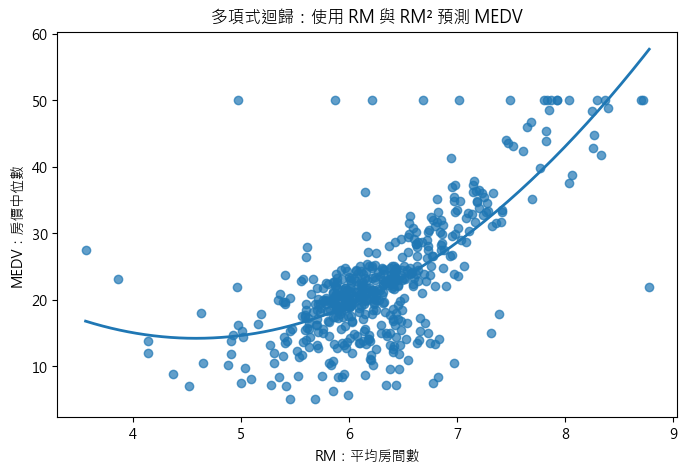

In [10]:
# ============================================================
# 7. 多項式迴歸：使用 RM 的二次特徵預測 MEDV
# ============================================================
# X_poly_source 保留 DataFrame 格式即可，不需要先轉成 NumPy array。

work = data.copy()

X_poly_source = work[["RM"]]
y_poly = work["MEDV"]

poly_converter = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_converter.fit_transform(X_poly_source)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_poly)

poly_pred = poly_model.predict(X_poly)
poly_rmse = np.sqrt(mean_squared_error(y_poly, poly_pred))
poly_r2 = r2_score(y_poly, poly_pred)

print("二次多項式迴歸")
print("轉換後的特徵名稱：", poly_converter.get_feature_names_out(["RM"]))
print("RMSE：", round(poly_rmse, 4))
print("R²：", round(poly_r2, 4))

rm_min = X_poly_source["RM"].min()
rm_max = X_poly_source["RM"].max()
x_curve = np.linspace(rm_min, rm_max, 200).reshape(-1, 1)
x_curve_df = pd.DataFrame(x_curve, columns=["RM"])
x_curve_poly = poly_converter.transform(x_curve_df)
y_curve = poly_model.predict(x_curve_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X_poly_source["RM"], y_poly, alpha=0.7)
plt.plot(x_curve, y_curve, linewidth=2)
plt.xlabel("RM：平均房間數")
plt.ylabel("MEDV：房價中位數")
plt.title("多項式迴歸：使用 RM 與 RM² 預測 MEDV")
plt.show()

## 8. 隨機森林迴歸

隨機森林迴歸是由多棵決策樹組成的集成模型。

對迴歸問題而言，隨機森林會讓每棵樹各自預測一個數值，最後取平均：

$$
\hat{y} = \frac{1}{B}\sum_{b=1}^{B}\hat{y}^{(b)}
$$

它常用來處理非線性關係，也可以提供特徵重要性。


隨機森林迴歸測試結果
RMSE： 4.2985
MAE： 2.7463
R²： 0.7731


,特徵,重要性
5,RM,0.4335
12,LSTAT,0.4122
0,CRIM,0.0378
7,DIS,0.0352
10,PTRATIO,0.0199
4,NOX,0.0195
9,TAX,0.0156
6,AGE,0.0085
2,INDUS,0.0064
11,B,0.0056


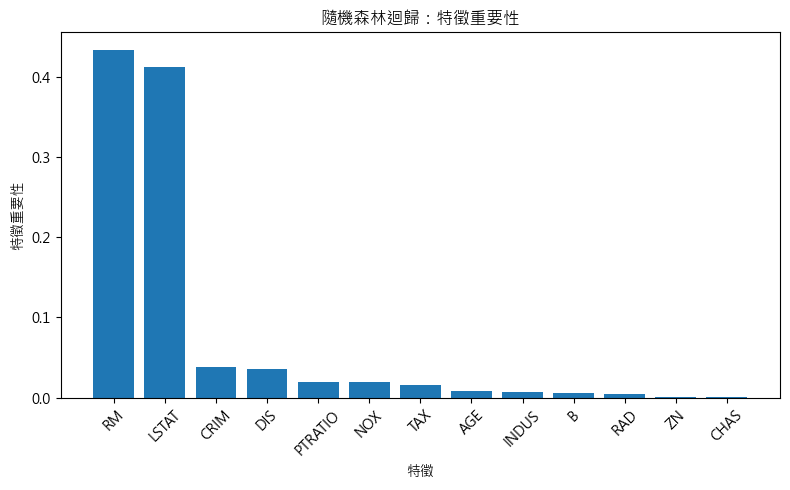

In [11]:
# ============================================================
# 8. 隨機森林迴歸
# ============================================================
# 本章教材提到隨機森林迴歸，這裡示範基本使用方式。
# n_estimators 是樹的數量，max_depth 是每棵樹最多可以長多深。
#
# 補充：
# 隨機森林是樹模型，主要根據特徵切分點建立規則，
# 通常不需要像線性模型、Ridge、Lasso 那樣先做標準化。

forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=0
)

forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)

forest_rmse = np.sqrt(mean_squared_error(y_test, forest_pred))
forest_mae = mean_absolute_error(y_test, forest_pred)
forest_r2 = r2_score(y_test, forest_pred)

print("隨機森林迴歸測試結果")
print("RMSE：", round(forest_rmse, 4))
print("MAE：", round(forest_mae, 4))
print("R²：", round(forest_r2, 4))

importance_table = pd.DataFrame({
    "特徵": feature_names,
    "重要性": forest_model.feature_importances_
})
importance_table = importance_table.sort_values("重要性", ascending=False)
display(importance_table.round(4))

plt.figure(figsize=(8, 5))
plt.bar(importance_table["特徵"], importance_table["重要性"])
plt.xticks(rotation=45)
plt.xlabel("特徵")
plt.ylabel("特徵重要性")
plt.title("隨機森林迴歸：特徵重要性")
plt.tight_layout()
plt.show()